<a href="https://colab.research.google.com/github/TurkayAydogan/ATAT/blob/Ver4/ATAT4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)
# Çıktıda "T4" veya "A100" görmelisiniz

Sun May 10 10:04:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
import dask.dataframe as dd
import pandas as pd
import numpy as np

# 1. Google Drive'a bağlanma
drive.mount('/content/drive')

print("\n1. Google Drive'dan veri Dask ile okunuyor...")
DATA_PATH = '/content/drive/MyDrive/CICIDS2017/*.csv'

df = dd.read_csv(
    DATA_PATH,
    assume_missing=True,
    dtype='object',
    on_bad_lines='skip'
)

# Sütun isimlerinin başındaki/sonundaki boşlukları temizle
df.columns = df.columns.str.strip()

# 2. Sayısal dönüşüm ve RAM tasarrufu için Downcasting (float64 -> float32)
print("2. Veri tipleri optimize ediliyor (RAM tasarrufu)...")
for col in df.columns:
    if col != 'Label':
        df[col] = dd.to_numeric(df[col], errors='coerce')

float_cols = [c for c in df.columns if c != 'Label']
for col in float_cols:
    df[col] = df[col].astype('float32')

# 3. Pandas'a geçiş (Hata aldığın df_pd işte burada oluşuyor!)
print("3. Dask'tan Pandas'a geçiliyor (Lütfen 1-2 dakika bekleyin)...")
df_pd = df.compute()

print(f"\n✅ İŞLEM TAMAM! Veri başarıyla RAM'e yüklendi.")
print(f"✅ Veri Boyutu (Shape): {df_pd.shape}")
print(f"✅ RAM Kullanımı: {df_pd.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

1. Google Drive'dan veri Dask ile okunuyor...
2. Veri tipleri optimize ediliyor (RAM tasarrufu)...
3. Dask'tan Pandas'a geçiliyor (Lütfen 1-2 dakika bekleyin)...

✅ İŞLEM TAMAM! Veri başarıyla RAM'e yüklendi.
✅ Veri Boyutu (Shape): (2830743, 79)
✅ RAM Kullanımı: 0.95 GB


In [3]:
# Tek bir dosyayı (ATAT2.ipynb) GitHub'dan indirmek için 'raw' linkini kullanmalıyız:
!wget https://raw.githubusercontent.com/TurkayAydogan/ATAT/Ver3/ATAT3.ipynb

print('\nDosya başarıyla indirildi. Sol taraftaki klasör simgesine tıklayarak görebilirsiniz.')

--2026-05-10 10:09:34--  https://raw.githubusercontent.com/TurkayAydogan/ATAT/Ver3/ATAT3.ipynb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 405213 (396K) [text/plain]
Saving to: ‘ATAT3.ipynb.1’

ATAT3.ipynb.1       100%[===================>] 395.72K  --.-KB/s    in 0.01s   

2026-05-10 10:09:35 (26.7 MB/s) - ‘ATAT3.ipynb.1’ saved [405213/405213]


Dosya başarıyla indirildi. Sol taraftaki klasör simgesine tıklayarak görebilirsiniz.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import time

print("--- HIZLI FAZ 3: Temizlik, Seçim ve Ölçekleme ---")
df_clean = df_pd.copy()
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# 1. Eksik Veri Doldurma
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# 2. Label Encoding ve Split
le = LabelEncoder()
y = le.fit_transform(df_clean['Label'])
X = df_clean.drop('Label', axis=1).select_dtypes(include=[np.number])
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Korelasyon ve Information Gain
corr_matrix = pd.DataFrame(X_train).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
X_train_corr = X_train.drop(columns=high_corr_cols)
X_test_corr  = X_test.drop(columns=high_corr_cols)

print("Information Gain hesaplanıyor (1-2 dk sürebilir)...")
mi_scores = mutual_info_classif(X_train_corr, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_corr.columns).sort_values(ascending=False)
selected_features = mi_series.head(25).index.tolist()

# 4. Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_corr[selected_features])
X_test_scaled  = scaler.transform(X_test_corr[selected_features])

print("✅ VERİ k-MEANS İÇİN HAZIR! Boyut:", X_train_scaled.shape)

--- HIZLI FAZ 3: Temizlik, Seçim ve Ölçekleme ---
Information Gain hesaplanıyor (1-2 dk sürebilir)...
✅ VERİ k-MEANS İÇİN HAZIR! Boyut: (2264594, 25)


--- FAZ 8.1: Optimal Küme Sayısı (Elbow Method) ---
⏳ Farklı k değerleri için hesaplanıyor... (Lütfen bekleyin)
k=2 hesaplandı.
k=3 hesaplandı.
k=4 hesaplandı.
k=5 hesaplandı.
k=6 hesaplandı.
k=7 hesaplandı.
k=8 hesaplandı.
k=9 hesaplandı.
k=10 hesaplandı.
k=11 hesaplandı.
k=12 hesaplandı.
k=13 hesaplandı.
k=14 hesaplandı.
k=15 hesaplandı.


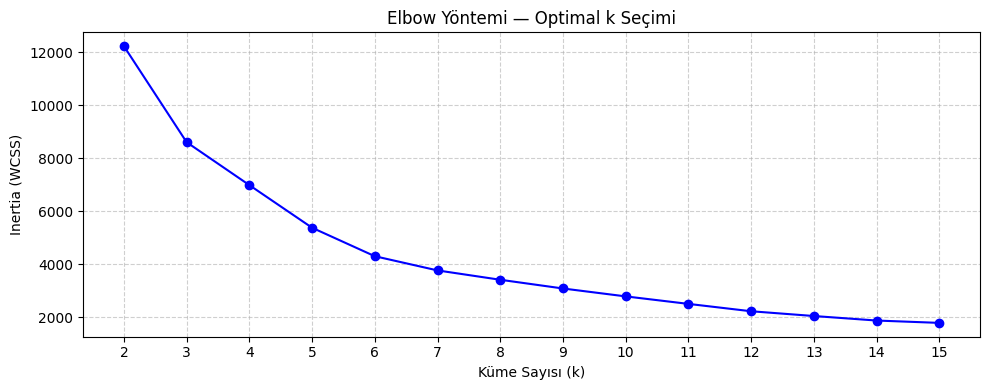

In [5]:
print("--- FAZ 8.1: Optimal Küme Sayısı (Elbow Method) ---")

# Etiketler gizli! Sadece matematiksel uzaklıklara bakıyoruz.
# Hız için 50.000 rastgele örneklem alıyoruz.
import numpy as np
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), size=50000, replace=False)
X_sample = X_train_scaled[sample_idx]

inertia_list = []
k_range = range(2, 16)

print("⏳ Farklı k değerleri için hesaplanıyor... (Lütfen bekleyin)")
from sklearn.cluster import KMeans
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertia_list.append(km.inertia_)
    print(f"k={k} hesaplandı.")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(k_range, inertia_list, 'bo-', markersize=6)
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Yöntemi — Optimal k Seçimi')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('elbow.png', dpi=150)
plt.show()

--- FAZ 8.2: k-Means Eğitimi (k=6) ---
✅ k-Means Eğitimi Tamamlandı. Oluşturulan küme sayısı: 6
Test setindeki küme dağılımı: Counter({np.int32(0): 340257, np.int32(3): 79462, np.int32(2): 66881, np.int32(1): 35566, np.int32(5): 24357, np.int32(4): 19626})

--- FAZ 8.3: Küme vs. Gerçek Etiket Karşılaştırması ---
Her kümedeki baskın sınıf (Küme Saflığı):
  Küme 0: Baskın Sınıf -> BENIGN (Saflık: %84.4)
  Küme 1: Baskın Sınıf -> BENIGN (Saflık: %98.8)
  Küme 2: Baskın Sınıf -> BENIGN (Saflık: %67.4)
  Küme 3: Baskın Sınıf -> BENIGN (Saflık: %96.0)
  Küme 4: Baskın Sınıf -> BENIGN (Saflık: %51.6)
  Küme 5: Baskın Sınıf -> DoS Hulk (Saflık: %78.1)

--- FAZ 8.4: PCA ile 2D Küme Görseli (Lejantlı Final Versiyonu) ---


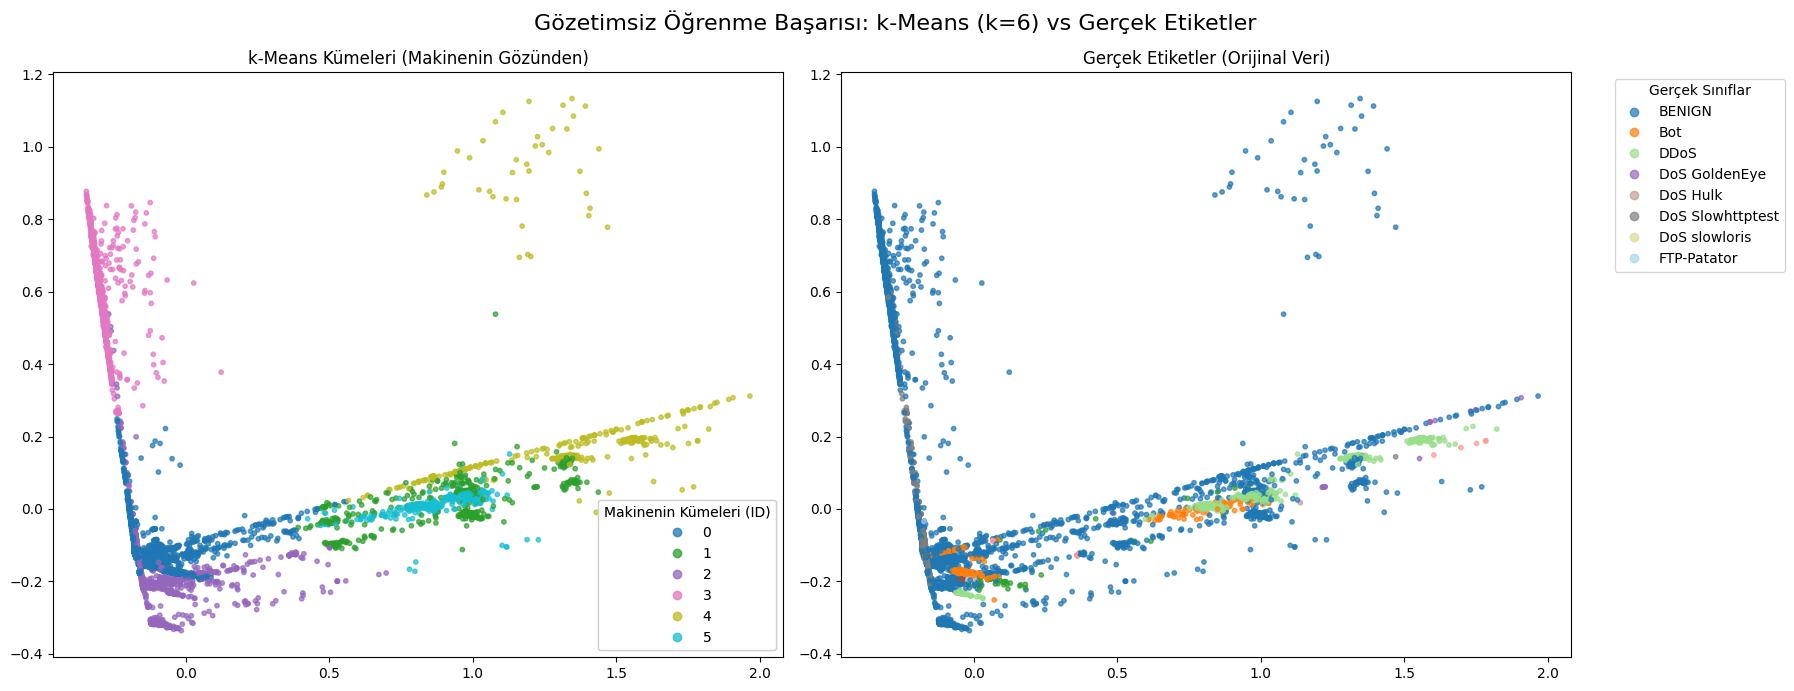

In [6]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("--- FAZ 8.2: k-Means Eğitimi (k=6) ---")

K_OPTIMAL = 6

# Modeli Etiketsiz (Label olmadan) Eğitiyoruz
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
km_final.fit(X_train_scaled)
cluster_labels = km_final.predict(X_test_scaled)

print(f"✅ k-Means Eğitimi Tamamlandı. Oluşturulan küme sayısı: {K_OPTIMAL}")
print(f"Test setindeki küme dağılımı: {Counter(cluster_labels)}")

print("\n--- FAZ 8.3: Küme vs. Gerçek Etiket Karşılaştırması ---")
# Her k-Means kümesinin içindeki gerçek label dağılımını hesaplıyoruz
cluster_df = pd.DataFrame({
    'Küme': cluster_labels,
    'Gerçek_Label': [class_names[i] for i in y_test]
})

print("Her kümedeki baskın sınıf (Küme Saflığı):")
for cluster_id in sorted(cluster_df['Küme'].unique()):
    subset = cluster_df[cluster_df['Küme']==cluster_id]
    dominant = subset['Gerçek_Label'].value_counts().idxmax()
    pct = subset['Gerçek_Label'].value_counts().iloc[0] / len(subset) * 100
    print(f"  Küme {cluster_id}: Baskın Sınıf -> {dominant} (Saflık: %{pct:.1f})")

print("\n--- FAZ 8.4: PCA ile 2D Küme Görseli (Lejantlı Final Versiyonu) ---")
# 25 boyutlu veriyi 2 boyuta (X, Y) indiriyoruz ki çizebilelim
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test_scaled[:10000])   # Görsel netliği için ilk 10.000 örneği alıyoruz
cluster_sample = cluster_labels[:10000]
true_sample = y_test[:10000]

# Çizim alanını lejantlar sığsın diye biraz daha genişletiyoruz (18, 7)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sol Grafik: Makinenin Kendi Oluşturduğu Kümeler
scatter1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=cluster_sample, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('k-Means Kümeleri (Makinenin Gözünden)')
# Küme ID'lerini (0'dan 5'e) gösteren lejantı ekliyoruz
legend1 = axes[0].legend(*scatter1.legend_elements(), title="Makinenin Kümeleri (ID)")
axes[0].add_artist(legend1)

# Sağ Grafik: Verinin Orijinal Gerçek Etiketleri
scatter2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=true_sample, cmap='tab20', s=10, alpha=0.7)
axes[1].set_title('Gerçek Etiketler (Orijinal Veri)')
# Gerçek saldırı isimlerini gösteren lejantı grafiğin dış sağ tarafına ekliyoruz
handles, labels = scatter2.legend_elements()
axes[1].legend(handles, class_names, title="Gerçek Sınıflar", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle(f'Gözetimsiz Öğrenme Başarısı: k-Means (k={K_OPTIMAL}) vs Gerçek Etiketler', fontsize=16)
plt.tight_layout()
plt.savefig('kmeans_vs_labels_legendli.png', dpi=150, bbox_inches='tight')
plt.show()